# Sample Analysis


In [ ]:
from pathlib import Path
import os
import re
from ANALYSIS_logging_utils import log_output, run_with_log

import numpy as np
import pandas as pd

from ANALYSIS_HW_HD_utils import *
from ANALYSIS_plots_utils import *
from ANALYSIS_create_npy_file import create_sample_npy_files
from reset_folder_notebook import reset_folder


In [ ]:
sample_registers = ["r0", "r1", "r2", "r3", "r4", "r5", "r6", "r7", "r8", "r9", "r10", "r11", "r12", "sp", "lr"]
sample_trace_dir = "output_decapsulation_sample_TRIM"
result_dir_sample = "Results_decapsulation_sample"
no_instructions = 500

reset_folder(result_dir_sample)
os.makedirs(Path(result_dir_sample) / "logs", exist_ok=True)


def create_sample_hw_hd_files():
    os.makedirs(result_dir_sample, exist_ok=True)

    hw_run_files = list(Path(result_dir_sample).glob("HW_run_*.npy"))
    hd_run_files = list(Path(result_dir_sample).glob("HD_run_*.npy"))

    print(f"Sample trace CSV files found: {len(list(Path(sample_trace_dir).glob('trace_*_*.csv')))}")
    print(f"Existing HW_run files: {len(hw_run_files)}")
    print(f"Existing HD_run files: {len(hd_run_files)}")

    create_sample_npy_files(result_dir_sample, sample_trace_dir, "HW", sample_registers)
    create_sample_npy_files(result_dir_sample, sample_trace_dir, "HD", sample_registers)


run_with_log(
    Path(result_dir_sample) / "logs" / "create_sample_hw_hd_files.txt",
    create_sample_hw_hd_files,
)

Sample trace CSV files found: 55
Existing HW_run files: 3
Existing HD_run files: 3
Creating sample simulation traces for model: HW
Found 50 sample trace files
Trace 0 has been converted
Run 0, fault 0 -> trace_0_0.csv
Run 0, fault 1 -> trace_0_1.csv
Run 0, fault 2 -> trace_0_2.csv
Run 0, fault 4 -> trace_0_4.csv
Run 0, fault 8 -> trace_0_8.csv
Run 0, fault 16 -> trace_0_16.csv
Run 0, fault 32 -> trace_0_32.csv
Run 0, fault 64 -> trace_0_64.csv
Run 0, fault 128 -> trace_0_128.csv
Run 0, fault 256 -> trace_0_256.csv
Run 1, fault 0 -> trace_1_0.csv
Run 1, fault 1 -> trace_1_1.csv
Run 1, fault 2 -> trace_1_2.csv
Run 1, fault 4 -> trace_1_4.csv
Run 1, fault 8 -> trace_1_8.csv
Run 1, fault 16 -> trace_1_16.csv
Run 1, fault 32 -> trace_1_32.csv
Run 1, fault 64 -> trace_1_64.csv
Run 1, fault 128 -> trace_1_128.csv
Run 1, fault 256 -> trace_1_256.csv
Run 2, fault 0 -> trace_2_0.csv
Run 2, fault 1 -> trace_2_1.csv
Run 2, fault 2 -> trace_2_2.csv
Run 2, fault 4 -> trace_2_4.csv
Run 2, fault 8 -> 

In [7]:
def load_sample_runs(result_dir, leakage_model):
    data_by_run = {}
    fault_order_by_run = {}

    for file in sorted(Path(result_dir).glob(f"{leakage_model}_run_*.npy")):
        match = re.search(r"run_(\d+)$", file.stem)
        if match is None:
            continue

        run_index = int(match.group(1))
        data_by_run[run_index] = np.load(file)

        order_path = Path(result_dir) / f"{leakage_model}_run_{run_index}_fault_order.csv"
        if order_path.exists():
            fault_order_by_run[run_index] = pd.read_csv(order_path)["fault_index"].astype(int).tolist()
        else:
            fault_order_by_run[run_index] = list(range(data_by_run[run_index].shape[0]))

    return data_by_run, fault_order_by_run


def load_and_describe_sample_runs():
    data_HW_sample, hw_fault_order = load_sample_runs(result_dir_sample, "HW")
    data_HD_sample, hd_fault_order = load_sample_runs(result_dir_sample, "HD")

    print("Information about data_HW_sample")
    print("--------------------------------")
    for run_index, data in sorted(data_HW_sample.items()):
        print(f"Run {run_index}, fault order: {hw_fault_order[run_index]}")
        information(data)

    print("\nInformation about data_HD_sample")
    print("--------------------------------")
    for run_index, data in sorted(data_HD_sample.items()):
        print(f"Run {run_index}, fault order: {hd_fault_order[run_index]}")
        information(data)

    return data_HW_sample, hw_fault_order, data_HD_sample, hd_fault_order


data_HW_sample, hw_fault_order, data_HD_sample, hd_fault_order = run_with_log(
    Path(result_dir_sample) / "logs" / "load_sample_runs.txt",
    load_and_describe_sample_runs,
)

Information about data_HW_sample
--------------------------------
Run 0, fault order: [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
The shape of the data is: (10, 29237)
The type of the data is: float64
The first 2 traces are: [[ 77.  79.  80. ... 155. 145. 143.]
 [ 77.  79.  80. ... 150. 140. 138.]]
If there are any NaN values: False
Run 1, fault order: [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
The shape of the data is: (10, 29237)
The type of the data is: float64
The first 2 traces are: [[ 77.  79.  80. ... 160. 150. 148.]
 [ 77.  79.  80. ... 159. 149. 147.]]
If there are any NaN values: False
Run 2, fault order: [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
The shape of the data is: (10, 29237)
The type of the data is: float64
The first 2 traces are: [[ 77.  79.  80. ... 158. 148. 146.]
 [ 77.  79.  80. ... 157. 147. 145.]]
If there are any NaN values: False
Run 3, fault order: [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
The shape of the data is: (10, 29237)
The type of the data is: float64
The first 2 trac

Base fault 1 HW runs: [0, 1, 2, 3, 4]
Base fault 1 HD runs: [0, 1, 2, 3, 4]

Top 3 SNR values for HW fault 1 vs fault 2 across runs:
1. instruction index = 14635, SNR = 112.45564516129018
2. instruction index = 17827, SNR = 89.65333333333324
3. instruction index = 16915, SNR = 89.65333333333324

Top 3 SNR values for HD fault 1 vs fault 2 across runs:
1. instruction index = 26, SNR = 1134.0
2. instruction index = 21938, SNR = 798.0625000000002
3. instruction index = 9154, SNR = 640.6666666666667

Top 3 SNR values for HW fault 1 vs fault 4 across runs:
1. instruction index = 16460, SNR = 488.13559322033893
2. instruction index = 14635, SNR = 377.9999999999996
3. instruction index = 16459, SNR = 281.82272727272704

Top 3 SNR values for HD fault 1 vs fault 4 across runs:
1. instruction index = 939, SNR = 2281.5
2. instruction index = 26, SNR = 1134.0
3. instruction index = 21938, SNR = 798.0625000000002

Top 3 SNR values for HW fault 1 vs fault 8 across runs:
1. instruction index = 7333, S

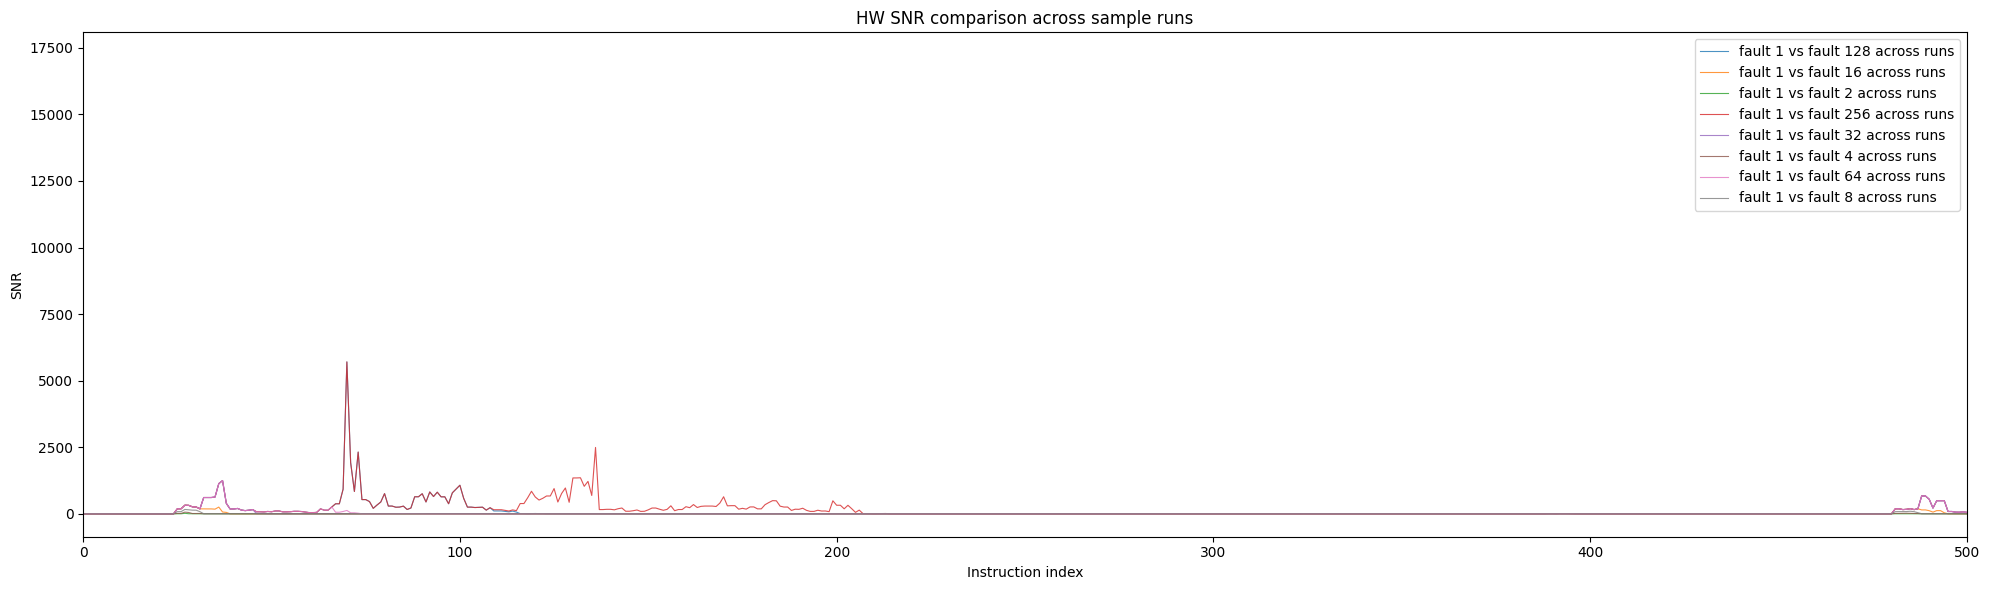

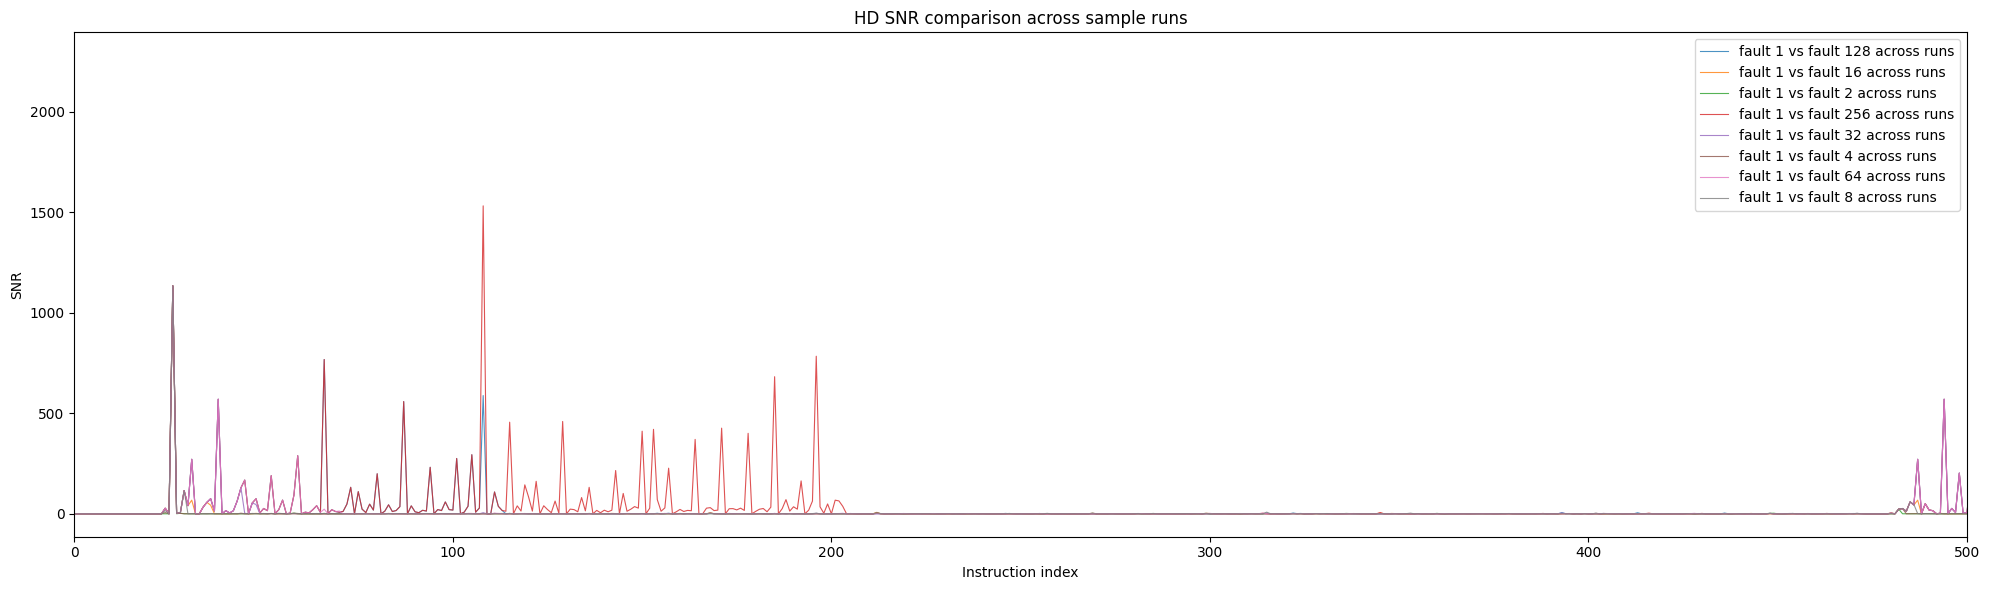

In [8]:
base_fault = 1
faults_to_compare = [2, 4, 8, 16, 32, 64, 128, 256, 512]


def stack_fault_across_runs(data_by_run, fault_order_by_run, fault):
    traces = []
    used_runs = []

    for run_index, data in sorted(data_by_run.items()):
        fault_to_row = {fault_value: row for row, fault_value in enumerate(fault_order_by_run[run_index])}
        if fault not in fault_to_row:
            continue

        traces.append(data[fault_to_row[fault]])
        used_runs.append(run_index)

    if not traces:
        return None, []

    min_len = min(len(trace) for trace in traces)
    return np.array([trace[:min_len] for trace in traces]), used_runs


def compute_and_plot_sample_snr():
    base_hw_traces, base_hw_runs = stack_fault_across_runs(data_HW_sample, hw_fault_order, base_fault)
    base_hd_traces, base_hd_runs = stack_fault_across_runs(data_HD_sample, hd_fault_order, base_fault)

    if base_hw_traces is None:
        raise ValueError(f"Base fault {base_fault} not found in HW data")
    if base_hd_traces is None:
        raise ValueError(f"Base fault {base_fault} not found in HD data")

    print(f"Base fault {base_fault} HW runs: {base_hw_runs}")
    print(f"Base fault {base_fault} HD runs: {base_hd_runs}")

    snr_hw = {}
    snr_hd = {}

    for alt_fault in faults_to_compare:
        alt_hw_traces, alt_hw_runs = stack_fault_across_runs(data_HW_sample, hw_fault_order, alt_fault)
        alt_hd_traces, alt_hd_runs = stack_fault_across_runs(data_HD_sample, hd_fault_order, alt_fault)

        if alt_hw_traces is None or alt_hd_traces is None:
            print(f"Skipping fault {alt_fault}: not present in HW or HD data")
            continue

        common_hw_runs = sorted(set(base_hw_runs) & set(alt_hw_runs))
        common_hd_runs = sorted(set(base_hd_runs) & set(alt_hd_runs))

        if len(common_hw_runs) < 2 or len(common_hd_runs) < 2:
            print(
                f"Skipping fault {alt_fault}: SNR needs at least 2 runs per class "
                f"(HW runs={common_hw_runs}, HD runs={common_hd_runs})"
            )
            continue

        key = f"fault {base_fault} vs fault {alt_fault} across runs"

        snr_hw[key] = compute_snr(base_hw_traces, alt_hw_traces)
        snr_hd[key] = compute_snr(base_hd_traces, alt_hd_traces)

        print_top3_snr_indices(snr_hw[key], f"HW {key}")
        print_top3_snr_indices(snr_hd[key], f"HD {key}")

    plot_snr_combined(
        snr_hw,
        "HW SNR comparison across sample runs",
        os.path.join(result_dir_sample, "snr_HW_across_runs_combined.png"),
        no_instructions=no_instructions,
    )

    plot_snr_combined(
        snr_hd,
        "HD SNR comparison across sample runs",
        os.path.join(result_dir_sample, "snr_HD_across_runs_combined.png"),
        no_instructions=no_instructions,
    )

    return base_hw_traces, base_hw_runs, base_hd_traces, base_hd_runs, snr_hw, snr_hd


base_hw_traces, base_hw_runs, base_hd_traces, base_hd_runs, snr_hw, snr_hd = run_with_log(
    Path(result_dir_sample) / "logs" / "sample_snr_across_runs.txt",
    compute_and_plot_sample_snr,
)